# Tutorial - Three-Phase Induction Motor

This tutorial shows how to use the `MotorElement` class to simulate a **Three-Phase Induction Motor (TPIM)** in ROSS. The electromechanical model is written in a synchronous reference frame oriented by the rotor flux {cite:p}`wu2016high,novotny1996vector`: the stator and rotor flux linkages and the shaft speed are integrated in time with a 4th-order Runge-Kutta method, and the electromagnetic torque, shaft speed, stator currents and stator voltages are obtained from them.

The motor can be fed by three different electrical sources, each one with its own `run_*` method:

| Method | Source | Speed control |
|---|---|---|
| `.run_direct_on_line()` | Ideal three-phase AC source (`SourceAC`), with optional voltage harmonics and unbalance | None (direct-on-line start) |
| `.run_with_inverter_vf()` | Voltage source inverter with Space Vector PWM (SVPWM) modulation (`InverterVF`) | Open-loop scalar V/f |
| `.run_with_inverter_foc()` | Voltage source inverter with SVPWM modulation (`InverterFOC`) | Closed-loop indirect Field-Oriented Control (FOC) |

All of them return a `MotorResponseResults` object with the time histories of `electric_torque`, `load_torque`, `speed`, `currents` and `voltages`, and with plot methods that use [Plotly](https://plotly.com/python/).

>**Note**: `MotorElement` is **not** a structural element: it does not contribute to the mass, stiffness, damping or gyroscopic matrices assembled by `Rotor`. Its node `n` only identifies where the motor torque is applied on the shaft (torsional DOF). To couple the motor to a rotor model, use `Rotor.run_with_motor()`, as shown in Section 5.

In [1]:
import numpy as np
import plotly.graph_objects as go

import ross as rs
from ross.units import Q_

# Make sure the default renderer is set to 'notebook' for inline plots in Jupyter
import plotly.io as pio

pio.defaults.default_width = 1024
pio.renderers.default = "notebook"

/home/jguarato/Documents/LMEst/ross/venv/lib/python3.12/site-packages/ccp/__init__.py:120: UserWarning: /home/jguarato/Documents/LMEst/ross/docs/user_guide/librefprop.so.
REFPROP not configured. Automatically switching to EOS='HEOS' (CoolProp backend).
  _warnings.warn(


Good news: It is possible to use REFPROP on your system! However, the library 
could not be loaded. Please make sure that REFPROP is available on your system.

Neither found in current location nor found in system PATH.
If you already obtained a copy of REFPROP from http://www.nist.gov/srd/, 
add location of REFPROP to the PATH environment variable or your library path.

In case you do not use Windows, have a look at https://github.com/jowr/librefprop.so 
to find instructions on how to compile your own version of the REFPROP library.

COOLPROP_REFPROP_ROOT: ?
ALTERNATIVE_REFPROP_PATH: /home/jguarato/Documents/LMEst/ross/docs/user_guide
ERROR: Could not load REFPROP (librefprop.so) due to: /home/jguarato/Documents/LMEst/ross/docs/user_guide/librefprop.so: cannot open shared object file: No such file or directory. Make sure the library is in your system search path. In case you run 64bit Windows and you have a REFPROP license, try installing the 64bit DLL from NIST. 


# Section 1: Motor model

`MotorElement` is instantiated from the nominal (nameplate) data and the equivalent circuit parameters of the machine. The motor used throughout this tutorial is a **1.5 hp**, **127 V / 60 Hz**, **4-pole** TPIM with a nominal speed of **1710 RPM**:

| Parameter | Value | Description |
|---|---|---|
| `power_nom` | 1.5 hp | Nominal power |
| `voltage_nom` | 127 V | Nominal voltage |
| `speed_nom` | 1710 RPM | Nominal speed |
| `frequency_nom` | 60 Hz | Nominal frequency |
| `n_poles` | 4 | Number of poles |
| `stator_resistance` / `rotor_resistance` | 2.5 / 1.8 Ω | Stator / rotor resistance |
| `stator_reactance` / `rotor_reactance` | 1.3 / 1.3 Ω | Stator / rotor self-reactance |
| `mutual_reactance` | 43.08 Ω | Mutual reactance |
| `Ip_motor` / `Ip_load` | 0.0372 / 0 kg·m² | Polar moment of inertia of the motor / load |
| `viscosity_coeff` | 0 | Viscous friction coefficient |

The supply voltage and frequency (`voltage_net` and `frequency_net`) are only used by the direct-on-line start and default to the nominal values; the inverters set the voltage and frequency applied to the motor by themselves. The function `rs.motor_example()` returns a ready-to-use motor with equivalent parameters.

In [2]:
motor = rs.MotorElement(
    n=0,
    tag="TPIM",
    power_nom=Q_(1.5, "hp"),
    voltage_nom=127,
    speed_nom=Q_(1710, "RPM"),
    frequency_nom=Q_(60, "Hz"),
    n_poles=4,
    stator_resistance=2.5,
    rotor_resistance=1.8,
    stator_reactance=1.3,
    rotor_reactance=1.3,
    mutual_reactance=43.08,
    Ip_motor=0.0372,
    Ip_load=0.0,
    viscosity_coeff=0.0,
)
motor

MotorElement(n=0, tag='TPIM', power_nom=1118.5, voltage_nom=127.0, speed_nom=179.07, frequency_nom=376.99, n_poles=4, stator_resistance=2.5, rotor_resistance=1.8, stator_reactance=1.3, rotor_reactance=1.3, mutual_reactance=43.08, Ip_motor=0.0372, viscosity_coeff=0.0, Ip_load=0.0, voltage_net=127.0, frequency_net=376.99, initial_angle_net=0.34907, short_circuit_ratio_net=50.0, XR_ratio_net=80.0, scale_factor=1, color='#001969')

# Section 2: Direct-on-line start

In a direct-on-line (DOL) start, the motor is connected straight to the three-phase supply, represented by an ideal voltage source (`SourceAC`). This section first simulates a balanced sinusoidal supply and then a supply with voltage harmonics and unbalance.

## 2.1 Running

The main arguments of `.run_direct_on_line()` are:

- `t`: time points at which the solution is stored [s];

- `load_torque_entrance_time`: time at which the load torque is applied to the shaft [s];

- `load_torque_ratio`: load torque as a fraction of the nominal torque `motor.Tnom` (1.0 = 100%).

In this example, the motor starts without load and the nominal torque is applied at t = 1.5 s.

In [3]:
dt = 1e-3
tf = 3.0
t = np.arange(0, tf + dt, dt)

results_dol = motor.run_direct_on_line(
    t,
    load_torque_entrance_time=1.5,
    load_torque_ratio=1.0,
)

## 2.2 Plotting time response

`.plot_torque()` shows the electromagnetic torque together with the load torque:

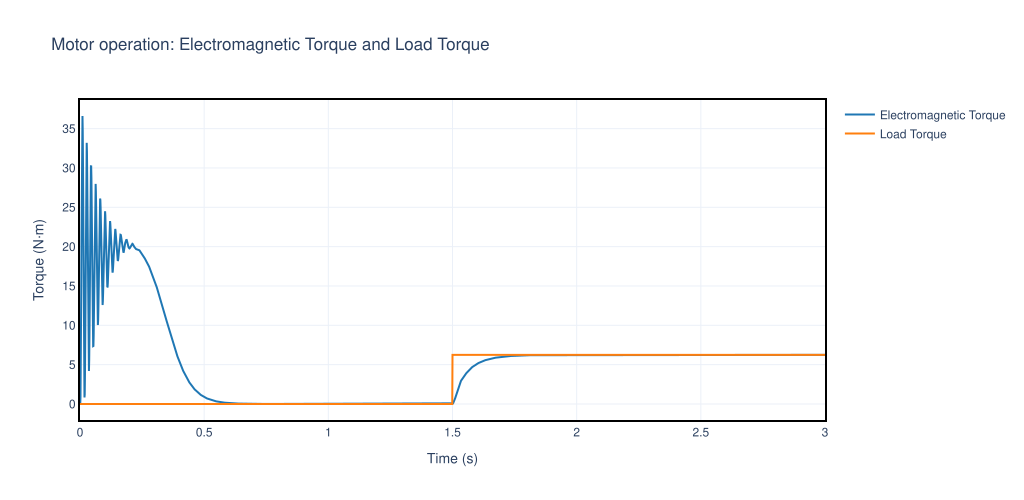

In [4]:
results_dol.plot_torque().show(renderer="svg")

`.plot_speed()` shows the shaft speed. The motor accelerates up to the synchronous speed (1800 RPM) and, after the load is applied, settles close to the nominal speed (1710 RPM) because of the slip:

In [5]:
results_dol.plot_speed().show()

The stator currents are plotted with `.plot_phase_currents()`. The `reference_frame` argument selects the natural three-phase frame (`"a-b-c"`), the Clarke frame (`"alpha-beta"`) or the Park frame (`"d-q"`):

In [6]:
results_dol.plot_phase_currents(reference_frame="a-b-c").show()

The stator voltages are available both as phase voltages, with `.plot_phase_voltages()`, and as line voltages (AB, BC, CA), with `.plot_line_voltages()`:

In [7]:
results_dol.plot_phase_voltages().show()

The time-domain plot methods accept `time_range=(t_min, t_max)`, in seconds, which sets the x-axis range of the figure:

In [8]:
results_dol.plot_line_voltages(time_range=(0.1, 0.3)).show()

## 2.3 Voltage harmonics and unbalance

Voltage harmonics and unbalance are added to the source with the `harmonics` and `unbalances` dictionaries.

`harmonics` accepts:
- `enable`: enables the harmonic content of the source;

- `orders`: list of harmonic orders;

- `amplitudes`: list of harmonic amplitudes, as a percentage of the supply voltage.

`unbalances` accepts:
- `enable`: enables the voltage unbalance;

- `voltage_percent`: voltage magnitude deviation of phases A, B and C [%];

- `angle_deviation`: voltage angle deviation of phases A, B and C.

In this example, the supply contains a 5th harmonic (300 Hz) with 3% amplitude and a 7th harmonic (420 Hz) with 2% amplitude, and the following unbalance:

| Phase | Voltage deviation | Angle deviation |
|---|---|---|
| A | -1% | +1° |
| B | +2% | 0° |
| C | +3% | -2° |

In [9]:
results_d = motor.run_direct_on_line(
    t,
    load_torque_entrance_time=1.5,
    load_torque_ratio=1.0,
    harmonics={
        "enable": True,
        "orders": [5, 7],
        "amplitudes": [3.0, 2.0],
    },
    unbalances={
        "enable": True,
        "voltage_percent": [-1.0, 2.0, 3.0],
        "angle_deviation": Q_([1.0, 0.0, -2.0], "deg"),
    },
)

## 2.4 Plotting frequency response

Every plot method accepts `domain="frequency"`, which shows the windowed FFT of the signal instead of its time history. The spectrum of the phase voltages shows the fundamental (60 Hz) and the injected 5th and 7th harmonics:

In [10]:
results_d.plot_phase_voltages(domain="frequency").show()

The same harmonics (300 Hz and 420 Hz) appear in the stator currents:

In [11]:
results_d.plot_phase_currents(domain="frequency").show()

In the electromagnetic torque, the distortion appears as ripple: the unbalance produces a component at twice the supply frequency (120 Hz), while the harmonics produce components at 240 Hz and 360 Hz:

In [12]:
results_d.plot_torque(domain="frequency").show()

# Section 3: Variable frequency drive with V/f adjustment technique

With `.run_with_inverter_vf()`, the motor is fed by a three-phase voltage source inverter (`InverterVF`) that uses SVPWM modulation and scalar V/f adjustment technique. The reference frequency increases linearly during an acceleration ramp, and the applied voltage changes in proportion to the frequency, which keeps the air-gap flux approximately constant. The speed control is open-loop: the inverter does not measure the shaft speed.

## 3.1 Running

Besides the arguments of `.run_direct_on_line()`, the main inverter arguments are:

- `frequency_s`: IGBT switching frequency;

- `time_ramp`: duration of the acceleration ramp, during which the reference frequency increases linearly from zero to `frequency_ref` [s];

- `frequency_ref`: V/f reference frequency. If `None`, half of the nominal frequency is used;

- `time_step`: time step of the numerical integration [s].

In this example, the switching frequency is 5 kHz and the reference frequency is **30 Hz**, half of the nominal frequency, so the synchronous speed is 900 RPM.

>**Note**: the SVPWM carrier is sampled every `time_step`, so `time_step` must be small compared to the switching period (200 µs at 5 kHz). As a rule of thumb, use at least 20 samples per switching period; otherwise, the carrier is aliased and the synthesized voltage is wrong. `time_step=1e-5` gives 20 samples per switching period.

In [13]:
switching_frequency = Q_(5000, "Hz")

results_vf = motor.run_with_inverter_vf(
    t,
    time_step=1e-6,
    load_torque_entrance_time=1.5,
    load_torque_ratio=1.0,
    frequency_s=switching_frequency,
    time_ramp=0.6667,
    frequency_ref=Q_(30, "Hz"),
)

## 3.2 Plotting time response

The V/f simulation is integrated with `time_step=1e-6`, so each signal has three million points. Drawing all of them would make the figures very heavy, so the plot methods downsample each trace with the MinMaxLTTB algorithm from [tsdownsample](https://github.com/predict-idlab/tsdownsample) package. For each trace it keeps the samples that define the shape of the curve, including its peaks and valleys, and the methods return an ordinary Plotly figure.

The number of samples is set by `n_shown_samples`, accepted by every motor plot method (`.plot_torque()`, `.plot_speed()`, `.plot_phase_currents()`, `.plot_phase_voltages()` and `.plot_line_voltages()`), in both `domain="time"` and `domain="frequency"`. If it is not given, the signals are downsampled to an equivalent time step of 0.1 ms.

Use larger values to resolve fine details, such as the switching ripple of the inverter, and smaller values for lighter figures. The selection is made once, when the figure is built, so zooming displays the samples already chosen.

In [14]:
results_vf.plot_torque(n_shown_samples=2000).show()

The effect of the argument is easier to see on the line voltages: with only 2000 points the individual PWM pulses can no longer be distinguished, although the envelope of the signal is still preserved:

In [15]:
results_vf.plot_line_voltages(n_shown_samples=2000).show()

In [16]:
results_vf.plot_phase_currents(n_shown_samples=2000).show()

The stator currents can also be displayed in the Park (d-q) reference frame, which is useful for analyzing the flux and torque-producing current components.

In [27]:
results_vf.plot_phase_currents(
    reference_frame="d-q", n_shown_samples=2000, time_range=(2.0, 2.5)
).show()

## 3.3 Plotting frequency response

The switching content of the inverter is concentrated around multiples of the switching frequency. The `frequency_range` argument limits the displayed band; here, it goes from 0.5 Hz, which discards the DC component, to 2.1 times the switching frequency, which includes the fundamental and the first two groups of switching harmonics:

In [18]:
results_vf.plot_line_voltages(
    domain="frequency", frequency_range=Q_((0, 50e3), "Hz"), n_shown_samples=2000
).show()

In [19]:
results_vf.plot_phase_currents(
    domain="frequency", frequency_range=Q_((0, 50e3), "Hz"), n_shown_samples=2000
).show()

# Section 4: Variable frequency drive with field-oriented control

With `.run_with_inverter_foc()`, the motor is fed by a voltage source inverter under indirect Field-Oriented Control (`InverterFOC`). Unlike `InverterVF`, this inverter operates in **closed loop**: at every time step it reads the rotor speed and the stator currents and regulates them with nested PI controllers, an outer speed loop and inner d-axis and q-axis current loops, written in the rotor flux reference frame {cite:p}`novotny1996vector`.

The arguments are the same as in `.run_with_inverter_vf()`. `frequency_ref` is the synchronous electrical frequency, which the speed loop converts to the mechanical speed reference `frequency_ref / (n_poles / 2)`.

>**Note**: since `InverterFOC` depends on the instantaneous state of the motor, the closed-loop simulation cannot be precomputed like the open-loop sources, and it takes longer than `.run_with_inverter_vf()` for the same `t` and `time_step`.

## 4.1 Running

The inverter parameters are the same as in Section 3, including the 30 Hz reference, so that both drives can be compared:

In [20]:
results_foc = motor.run_with_inverter_foc(
    t,
    time_step=1e-5,
    load_torque_entrance_time=1.5,
    load_torque_ratio=1.0,
    frequency_s=switching_frequency,
    time_ramp=0.6667,
    frequency_ref=Q_(30, "Hz"),
)

## 4.2 Plotting time response

The electromagnetic torque increases to balance the load torque applied at t = 1.5 s:

In [21]:
results_foc.plot_torque(n_shown_samples=2000).show()

## 4.3 Comparing V/f and FOC

The figure below shows the shaft speed obtained with both drives. The method `.sample_at()` returns the results at the time points `t` given to the simulation, instead of at every integration step. Before the load is applied, both drives reach the synchronous speed of 900 RPM. After the load is applied, the V/f drive settles at a lower speed because of the slip, while the speed loop of the FOC drive brings the shaft back to 900 RPM:

In [22]:
fig = go.Figure()
for name, results in [("V/f", results_vf), ("FOC", results_foc)]:
    fig.add_trace(
        go.Scatter(
            x=t,
            y=Q_(results.sample_at("speed"), "rad/s").to("RPM").m,
            name=name,
        )
    )
fig.update_layout(
    title="Shaft speed with V/f and FOC drives (frequency_ref = 30 Hz)",
    xaxis_title="Time (s)",
    yaxis_title="Speed (RPM)",
)
fig.show()

# Section 5: Coupling the motor to a rotor

`Rotor.run_with_motor()` combines the motor simulation with the rotor time response. It first simulates the motor with the selected drive and then integrates the rotor equations of motion with the Newmark method, applying:

- the net torque (electromagnetic torque minus load torque) to the torsional DOF of the motor node;

- the unbalance forces, computed with the shaft speed obtained from the motor simulation, which varies in time.

## 5.1 Rotor model

The motor is added to the rotor like any other element, with `add_elements()` or with the `motor_element` argument of `Rotor`. This example uses the shaft and disks of `rs.rotor_example()`, with damping added to the bearings.

The motor is at node 0, where it is drawn in the rotor plot:

In [23]:
base_rotor = rs.rotor_example()
bearings = [
    rs.BearingElement(n=bearing.n, kxx=1e6, cxx=2e3)
    for bearing in base_rotor.bearing_elements
]

rotor = rs.Rotor(
    base_rotor.shaft_elements,
    base_rotor.disk_elements,
    bearings,
    motor_element=motor,
)
rotor.plot_rotor().show()

## 5.2 Running

The main arguments of `.run_with_motor()` are:

- `node`, `unbalance_magnitude` and `unbalance_phase`: nodes, magnitudes [kg·m] and phases [rad] of the unbalances;

- `drive_mode`: electrical source of the motor: `"DOL"` (direct-on-line start, Section 2), `"VFD_VF"` (V/f adjustment, Section 3) or `"VFD_FOC"` (field-oriented control, Section 4);

- `load_torque_entrance_time` and `load_torque_ratio`: same as in the motor methods;

- `ac_source_harmonics` and `ac_source_unbalances`: same as `harmonics` and `unbalances` in `.run_direct_on_line()`, used only with `"DOL"`;

- `time_step`, `time_ramp` and `frequency_ref`: same as in the inverter methods, used only with `"VFD_VF"` and `"VFD_FOC"`. The switching frequency is fixed at 5 kHz;

- `steady_state`: if `True` (default), only the last third of the interval after the load torque is applied is integrated, which skips the motor start-up and the load transient. In this case, `load_torque_entrance_time` must be provided.

In this example, the motor is started direct-on-line, the nominal load is applied at t = 1.5 s, and an unbalance of 5e-4 kg·m is placed on the disk at node 2. The time step is reduced to 0.1 ms, which is suitable for the Newmark integration of the rotor:

In [24]:
t = np.arange(0, 3.0 + 1e-4, 1e-4)

results_rotor = rotor.run_with_motor(
    t=t,
    node=[2],
    unbalance_magnitude=[5e-4],
    unbalance_phase=[0],
    drive_mode="DOL",
    load_torque_entrance_time=1.5,
    load_torque_ratio=1.0,
)

## 5.3 Plotting results

The method returns a `TimeResponseResults` object, with the same plot methods as `.run_time_response()`. The motor results are stored in the `motor_results` attribute, a `MotorResponseResults` object like the ones used in the previous sections.

The displacement at the disk is measured with a probe:

In [25]:
probe = rs.Probe(2, 0)

results_rotor.plot_1d([probe]).show()

# References

```{bibliography}
:filter: docname in docnames
```